# Customer Churn — Exploratory Data Analysis

**Business question:** Which subscribers are most likely to churn, and which customer attributes drive that risk?

**Dataset:** 7,043 telecom subscribers × 21 features, with `Churn` as the binary target.

**Goals of this notebook**
- Inspect data quality and fix any structural issues
- Profile the target distribution
- Identify features that separate churners from non-churners
- Surface findings that will guide feature selection and modeling in the next notebook

**Contents**
1. Data Loading & Initial Look
2. Data Quality
3. Target Distribution
4. Univariate Analysis — Numerical Features
5. Bivariate Analysis — Features vs. Churn
6. Summary & Next Steps

## 1. Data Loading & Initial Look

In [20]:
import pandas as pd
df = pd.read_csv("../data/subscribers.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Global plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

# Consistent palette for churn comparisons (No -> blue, Yes -> orange)
CHURN_PALETTE = ["#4C72B0", "#DD8452"]

Each row represents a customer; each column is a customer attribute (full descriptions in the column dictionary below).

The raw dataset contains **7,043 customers** and **21 features**. `Churn` is our binary target.

In [22]:
df.shape

(7043, 21)

### 1.1 Column Dictionary
* **gender**: Whether the customer is male or female
* **SeniorCitizen**: Whether the customer is a senior citizen (1, 0)
* **Partner**: Whether the customer has a partner (Yes, No)
* **Dependents**: Whether the customer has dependents (Yes, No)
* **tenure**: Number of months the customer has stayed with the company
* **PhoneService**: Whether the customer has phone service (Yes, No)
* **MultipleLines**: Whether the customer has multiple lines (Yes, No, No phone service)
* **InternetService**: Customer's internet service provider (DSL, Fiber optic, No)
* **OnlineSecurity**: Whether the customer has online security (Yes, No, No internet service)
* **OnlineBackup**: Whether the customer has online backup (Yes, No, No internet service)
* **DeviceProtection**: Whether the customer has device protection (Yes, No, No internet service)
* **TechSupport**: Whether the customer has tech support (Yes, No, No internet service)
* **StreamingTV**: Whether the customer has streaming TV (Yes, No, No internet service)
* **StreamingMovies**: Whether the customer has streaming movies (Yes, No, No internet service)
* **Contract**: The contract term (Month-to-month, One year, Two year)
* **PaperlessBilling**: Whether the customer has paperless billing (Yes, No)
* **PaymentMethod**: Payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
* **MonthlyCharges**: Amount charged to the customer monthly
* **TotalCharges**: Total amount charged to the customer
* **Churn**: Whether the customer churned (Yes, No) — **target variable**

## 2. Data Quality

Before any analysis, we inspect dtypes, missing values, and any hidden anomalies that `isna()` alone won't catch.

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` is stored as a string despite being a monetary value — that's a red flag worth investigating before casting.

In [24]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
print(df['TotalCharges'].value_counts())

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64


There are **11 rows with whitespace** in `TotalCharges` that `isna()` doesn't catch. Let's look at these rows to decide whether to impute or drop.

In [26]:
df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


All 11 affected customers have `tenure = 0` — they're brand new and haven't completed a billing cycle, so the empty `TotalCharges` is *correct*, not missing. Since they cannot have churned yet, we drop them from the churn analysis and cast `TotalCharges` to float.

In [27]:
# Dropping empty TotalCharges rows
df = df[df["TotalCharges"] != ' ']
print(df.shape)

# Type casting TotalCharges feature to float
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Checking if changes worked
df.info()

(7032, 21)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  

## 3. Target Distribution

In [28]:
balance_analysis = pd.DataFrame({
    'Count': df['Churn'].value_counts(),
    'Percentage': df["Churn"].value_counts(normalize=True) * 100
})
print(balance_analysis)

       Count  Percentage
Churn                   
No      5163   73.421502
Yes     1869   26.578498


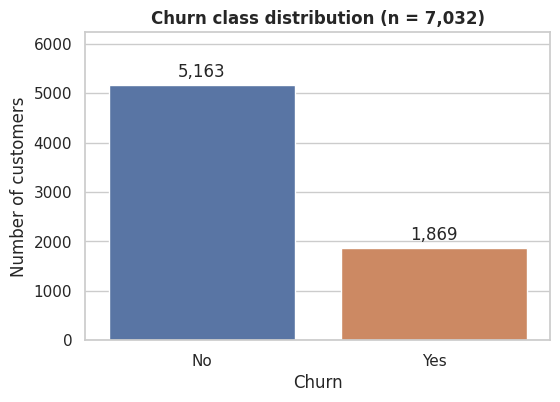

In [29]:
from matplotlib.container import BarContainer

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df["Churn"], hue=df["Churn"], palette=CHURN_PALETTE, legend=False)
for container in ax.containers:
    if isinstance(container, BarContainer):
        ax.bar_label(container, fmt="{:,.0f}", padding=3)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.title("Churn class distribution (n = 7,032)")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
plt.show()

Mild class imbalance (≈73/27). Two implications for the modeling phase:

- **Accuracy is a misleading metric here** — a model that always predicts "No" hits 73% accuracy without learning anything. Prefer **precision, recall, F1, and ROC-AUC**.
- We may need **imbalance-handling techniques** (class weights, resampling) to keep the model from biasing toward the majority class.

## 4. Univariate Analysis — Numerical Features

In [30]:
# Type-casting SeniorCitizen column first
df["SeniorCitizen"] = df["SeniorCitizen"].astype('category')

# 1. Get all numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# 2. Get all categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Drop identifier and target from categorical features list
cat_cols = [c for c in cat_cols if c not in ('customerID', 'Churn')]

# Let's see what we got
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [31]:
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


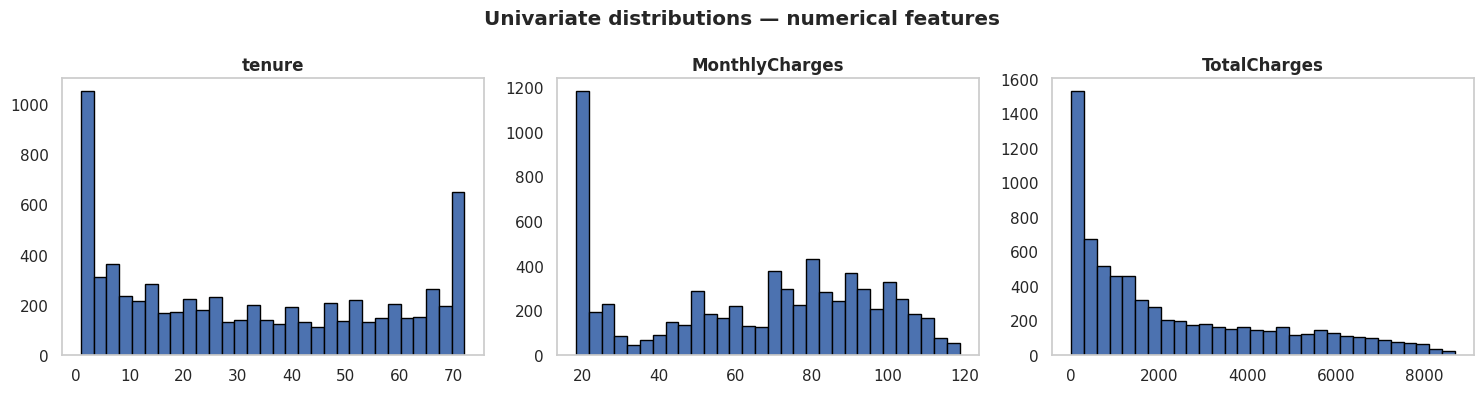

In [32]:
df[num_cols].hist(
    figsize=(15, 4),
    bins=30,
    edgecolor="black",
    color=CHURN_PALETTE[0],
    grid=False,
    layout=(1, 3),
)
plt.suptitle("Univariate distributions — numerical features", fontweight="bold")
plt.tight_layout()
plt.show()

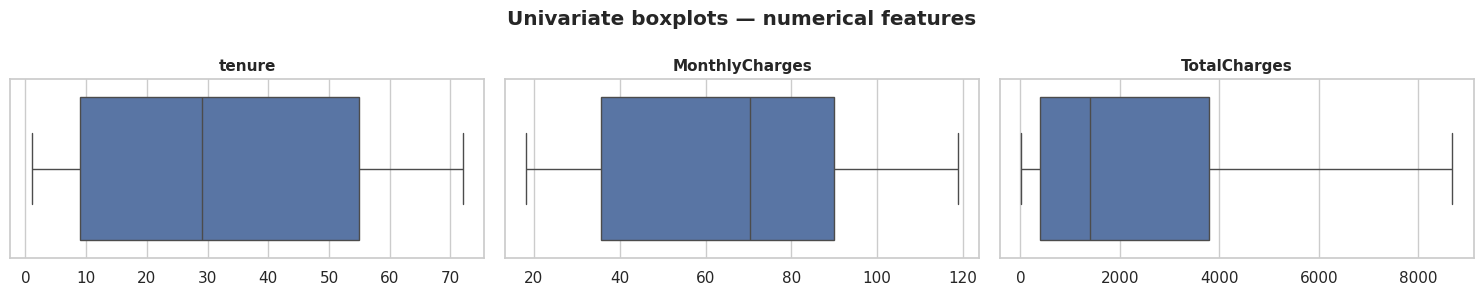

In [33]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(15, 3))

if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=CHURN_PALETTE[0])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

plt.suptitle("Univariate boxplots — numerical features", fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
# Calculate skewness for numerical features
df[num_cols].skew()

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64

**Univariate takeaways:**

- **`tenure`** (median 29mo, p25=9mo, p75=55mo, skew=+0.24): roughly bimodal — a large cohort of new customers (≤9mo) coexists with a long-tenure cohort approaching the 72mo cap. Distribution is near-symmetric.
- **`MonthlyCharges`** (median \$70.35, range \$18.25–\$118.75, skew=-0.22): wide spread, suggesting multiple pricing tiers. Low-price plans are the minority; most customers cluster in the \$70–\$120 range.
- **`TotalCharges`** (median \$1,397, mean \$2,283, skew=+0.96): strongly right-skewed, with a long tail driven by long-tenure customers accumulating charges. A **log transform** would be appropriate before any linear model.

## 5. Bivariate Analysis

### 5.1 Numerical Features vs. Churn

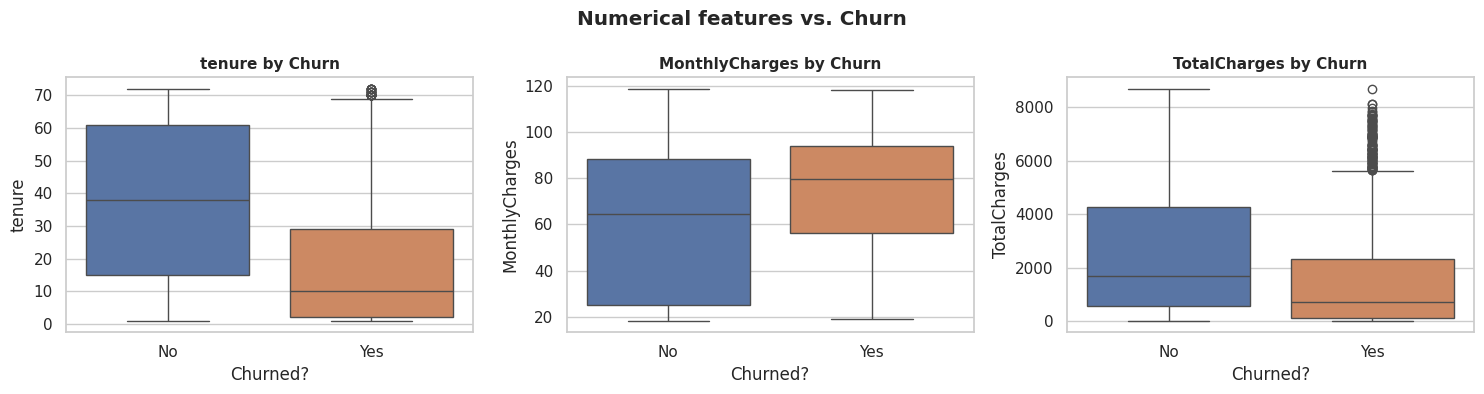

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(15, 4))

if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    sns.boxplot(
        x="Churn",
        y=col,
        data=df,
        ax=axes[i],
        hue="Churn",
        palette=CHURN_PALETTE,
        legend=False,
    )
    axes[i].set_title(f"{col} by Churn", fontsize=11)
    axes[i].set_xlabel("Churned?")
    axes[i].set_ylabel(col)

plt.suptitle("Numerical features vs. Churn", fontweight="bold")
plt.tight_layout()
plt.show()

**What the box plots reveal:**

- **`tenure` — strong separation.** Median tenure is **10 months for churners** vs **38 months for non-churners** — nearly a 4× gap. Tenure is likely the single strongest individual numerical predictor.
- **`MonthlyCharges` — meaningful but smaller gap.** Churners pay a median of **\$79.65/mo** vs **\$64.45/mo** for retained customers (≈24% higher). Higher-priced plans churn more.
- **`TotalCharges` — lower for churners** (median \$704 vs \$1,684), but this is largely a *consequence* of shorter tenure rather than an independent driver. We'll see this multicollinearity confirmed in the heatmap below (r ≈ 0.83 with tenure).

**Modeling implication:** `tenure` and `MonthlyCharges` look like high-signal predictors. `TotalCharges` is redundant with `tenure` and is a candidate for removal.

### 5.2 Correlation Heatmap (Numerical Features)

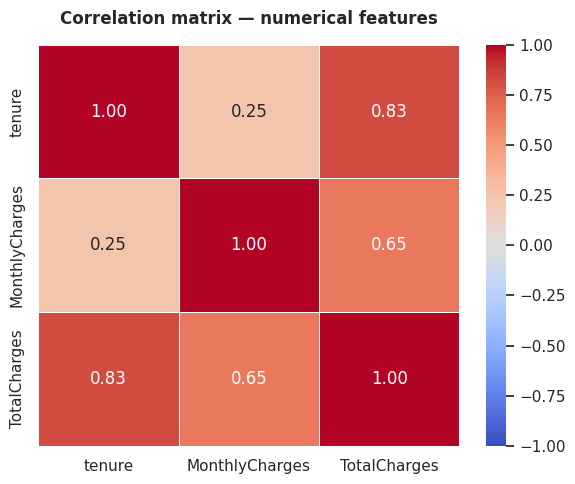

In [36]:
corr_matrix = df.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0,
)
plt.title("Correlation matrix — numerical features", pad=15)
plt.tight_layout()
plt.show()

**Heatmap takeaway:** `tenure` and `TotalCharges` are highly collinear (**r ≈ 0.83**) — keeping both in a linear model would inflate variance. **Plan: drop `TotalCharges`, keep `tenure`** as the more interpretable feature. `MonthlyCharges` is moderately correlated with `TotalCharges` (r ≈ 0.65) but largely independent of `tenure` (r ≈ 0.25), so it stays.

### 5.3 Categorical Features vs. Churn Rate

In [37]:
# converting target feature into 0s and 1s
df["Churn"] = df["Churn"].map({'Yes': 1, 'No': 0})

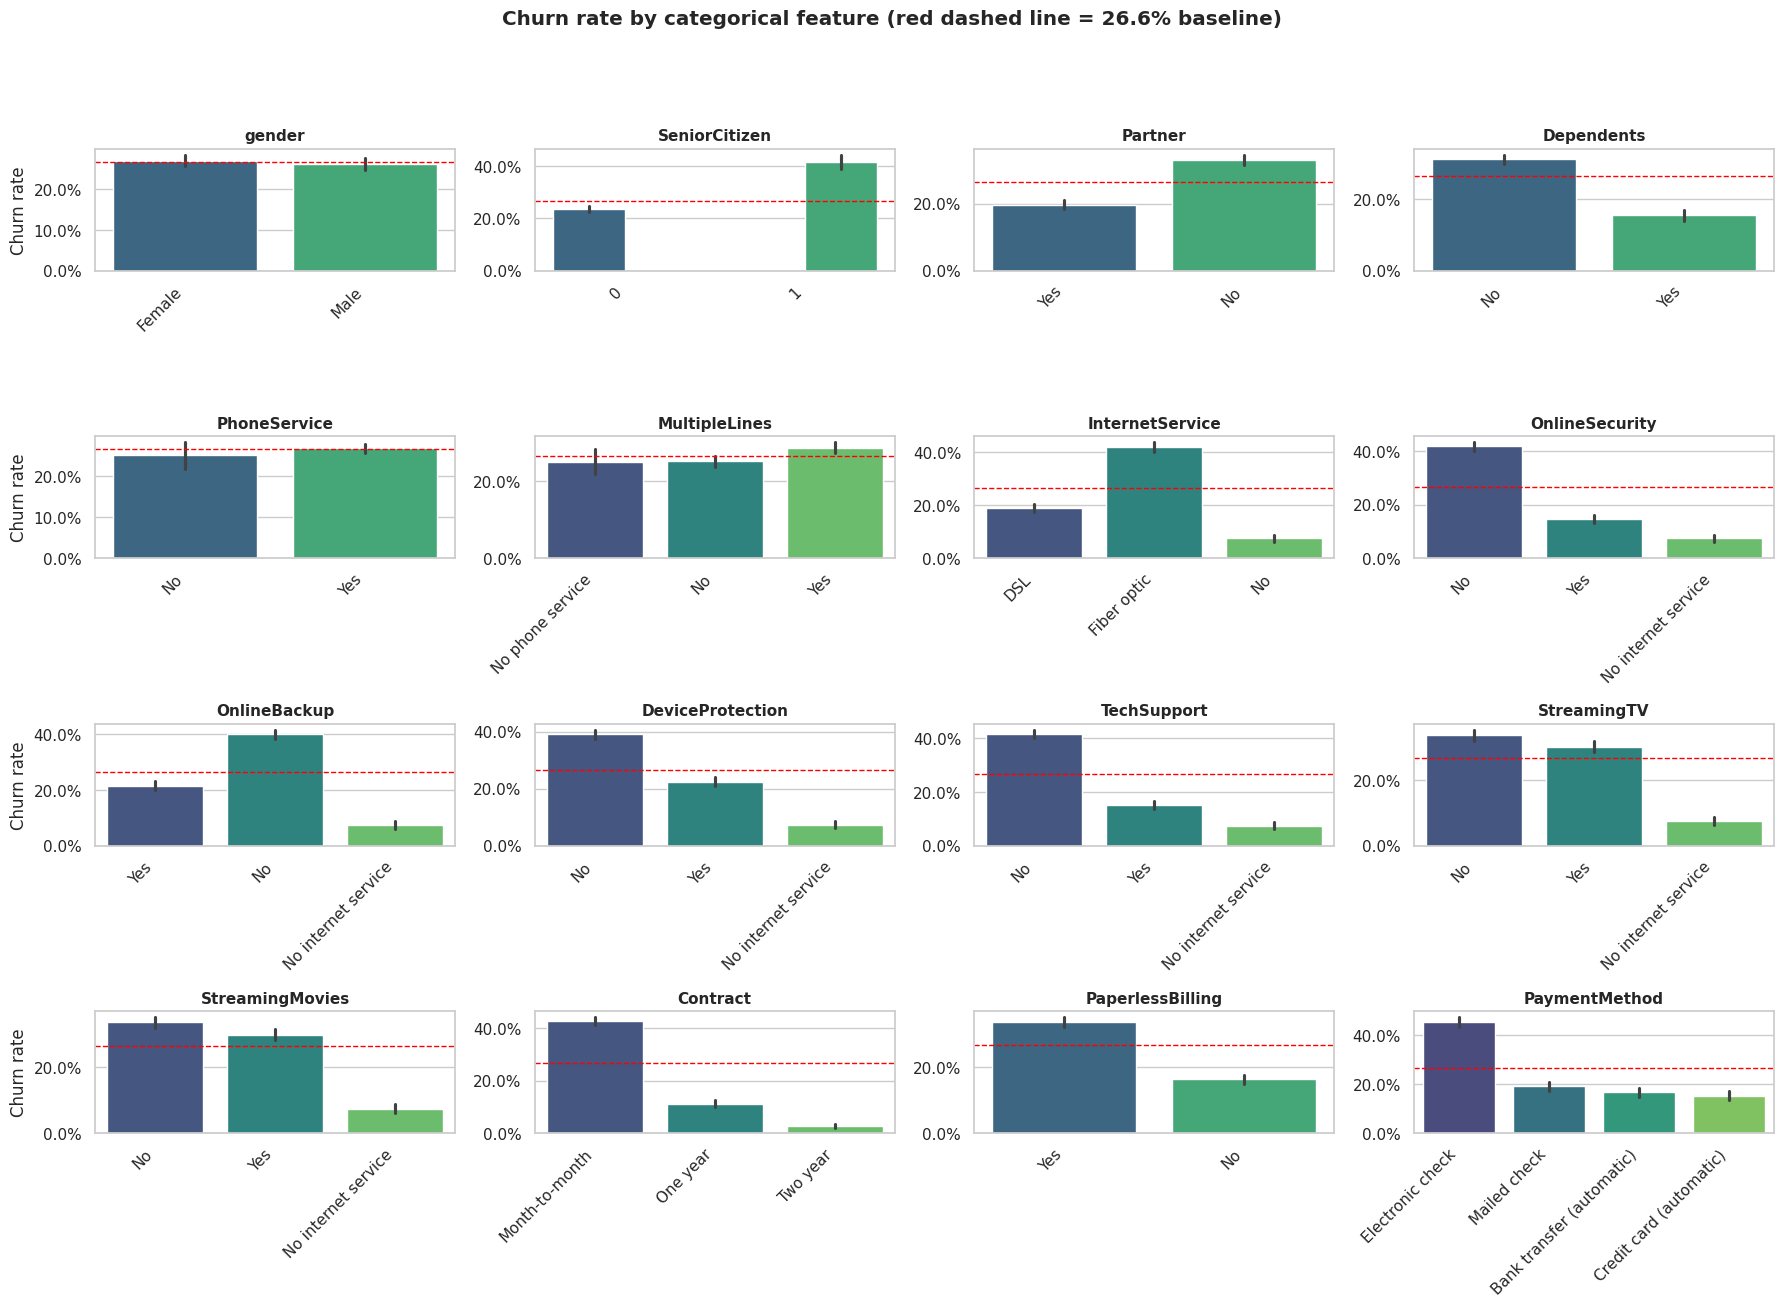

In [38]:
baseline = df["Churn"].mean()
ncols = 4
nrows = (len(cat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(
        x=col,
        y="Churn",
        data=df,
        ax=axes[i],
        hue=col,
        palette="viridis",
        legend=False,
    )
    axes[i].axhline(baseline, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    # Only label y-axis on the leftmost column
    axes[i].set_ylabel("Churn rate" if i % ncols == 0 else "")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    for label in axes[i].get_xticklabels():
        label.set_horizontalalignment("right")

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Churn rate by categorical feature (red dashed line = {baseline:.1%} baseline)",
    fontweight="bold",
    y=1.02,
)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

**Categorical takeaways** (baseline churn rate = **26.6%**):

- **`Contract`** is the single strongest predictor: month-to-month churns at **42.7%** vs **2.8%** for 2-year contracts — a ~15× gap.
- **`InternetService = Fiber optic`** churns at **41.9%**, more than 2× DSL (19.0%) and 5× no-internet (7.4%). Counter-intuitive given fiber is the premium product — worth investigating pricing, reliability, or onboarding.
- **`PaymentMethod = Electronic check`** churns at **45.3%** vs ~15–19% for the other three methods. Likely a proxy for less-committed customers.
- **Add-on services** all follow the same pattern — customers *without* OnlineSecurity, OnlineBackup, DeviceProtection, or TechSupport churn at ~40% vs ~15–22% for those who have them. These add-ons act as retention hooks.
- **Demographics** that elevate risk: SeniorCitizen (41.7% vs 23.7%), no Partner (33.0% vs 19.7%), no Dependents (31.3% vs 15.5%).
- **`PaperlessBilling = Yes`** churns at 33.6% vs 16.4% (No) — probably a digital-native / less-loyal segment.
- **No effect** (within noise): `gender` (27.0% vs 26.2%), `PhoneService`, `MultipleLines`, `StreamingTV`, `StreamingMovies`. Candidates for dropping during feature selection.

## 6. Summary & Next Steps

### Data Quality
- Started with 7,043 customers; dropped **11 with `tenure = 0`** (brand-new customers with no completed billing cycle, no churn opportunity yet) → final dataset = **7,032**.
- Cast `TotalCharges` from string to float (whitespace-only entries on the same 11 rows).
- No other missing values or anomalies detected.

### Key Findings (ordered by effect size)
1. **`Contract` is the dominant driver** — Month-to-month: **42.7%** vs Two year: **2.8%** (≈15× gap).
2. **`PaymentMethod = Electronic check`** — **45.3%** vs ~15–19% for the other three methods.
3. **`InternetService = Fiber optic`** — **41.9%** vs 19.0% DSL, 7.4% no-internet.
4. **`tenure`** — median **10mo (churned)** vs **38mo (retained)**, a ~4× gap.
5. **Missing add-on services** (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) — all churn at ~40% when absent vs ~15–22% when present.
6. **`SeniorCitizen`** — **41.7%** vs 23.7%.
7. **`MonthlyCharges`** — median **\$79.65** vs **\$64.45**, ~24% higher for churners.
8. **`PaperlessBilling`, no `Partner`, no `Dependents`** — moderate elevators (33–34% vs 16–20%).

### Modeling Implications
- **Class imbalance** (73/27): prefer **F1 / ROC-AUC** over accuracy; apply class weights or resampling.
- **Multicollinearity**: drop `TotalCharges` (r ≈ 0.83 with `tenure`); keep `tenure` for interpretability.
- **Skewness**: `TotalCharges` (skew +0.96) would need a **log transform** before any linear model — but since we're dropping it, this is mostly moot for the baseline model.
- **Drop-candidates** (no signal vs the 26.6% baseline): `gender`, `PhoneService`, `MultipleLines`, `StreamingTV`, `StreamingMovies`.
- **Likely-correlated predictors**: `Electronic check` + `Month-to-month` + `Fiber optic` may form a single "less-committed customer" cluster — investigate before treating them as independent features.

### Open Questions for the Modeling Notebook
- Why does **fiber-optic** — the premium product — churn at 2× the DSL rate? Pricing, network reliability, or customer mismatch? Worth a deeper segmentation.
- Is `PaymentMethod = Electronic check` an **independent driver** or just a **proxy** for `Contract = Month-to-month`? Cross-tabulate before modeling.
- Can the four add-on services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) be collapsed into a single "has protection bundle" indicator without losing signal?